First few rows of the classification dataset:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny  
3       

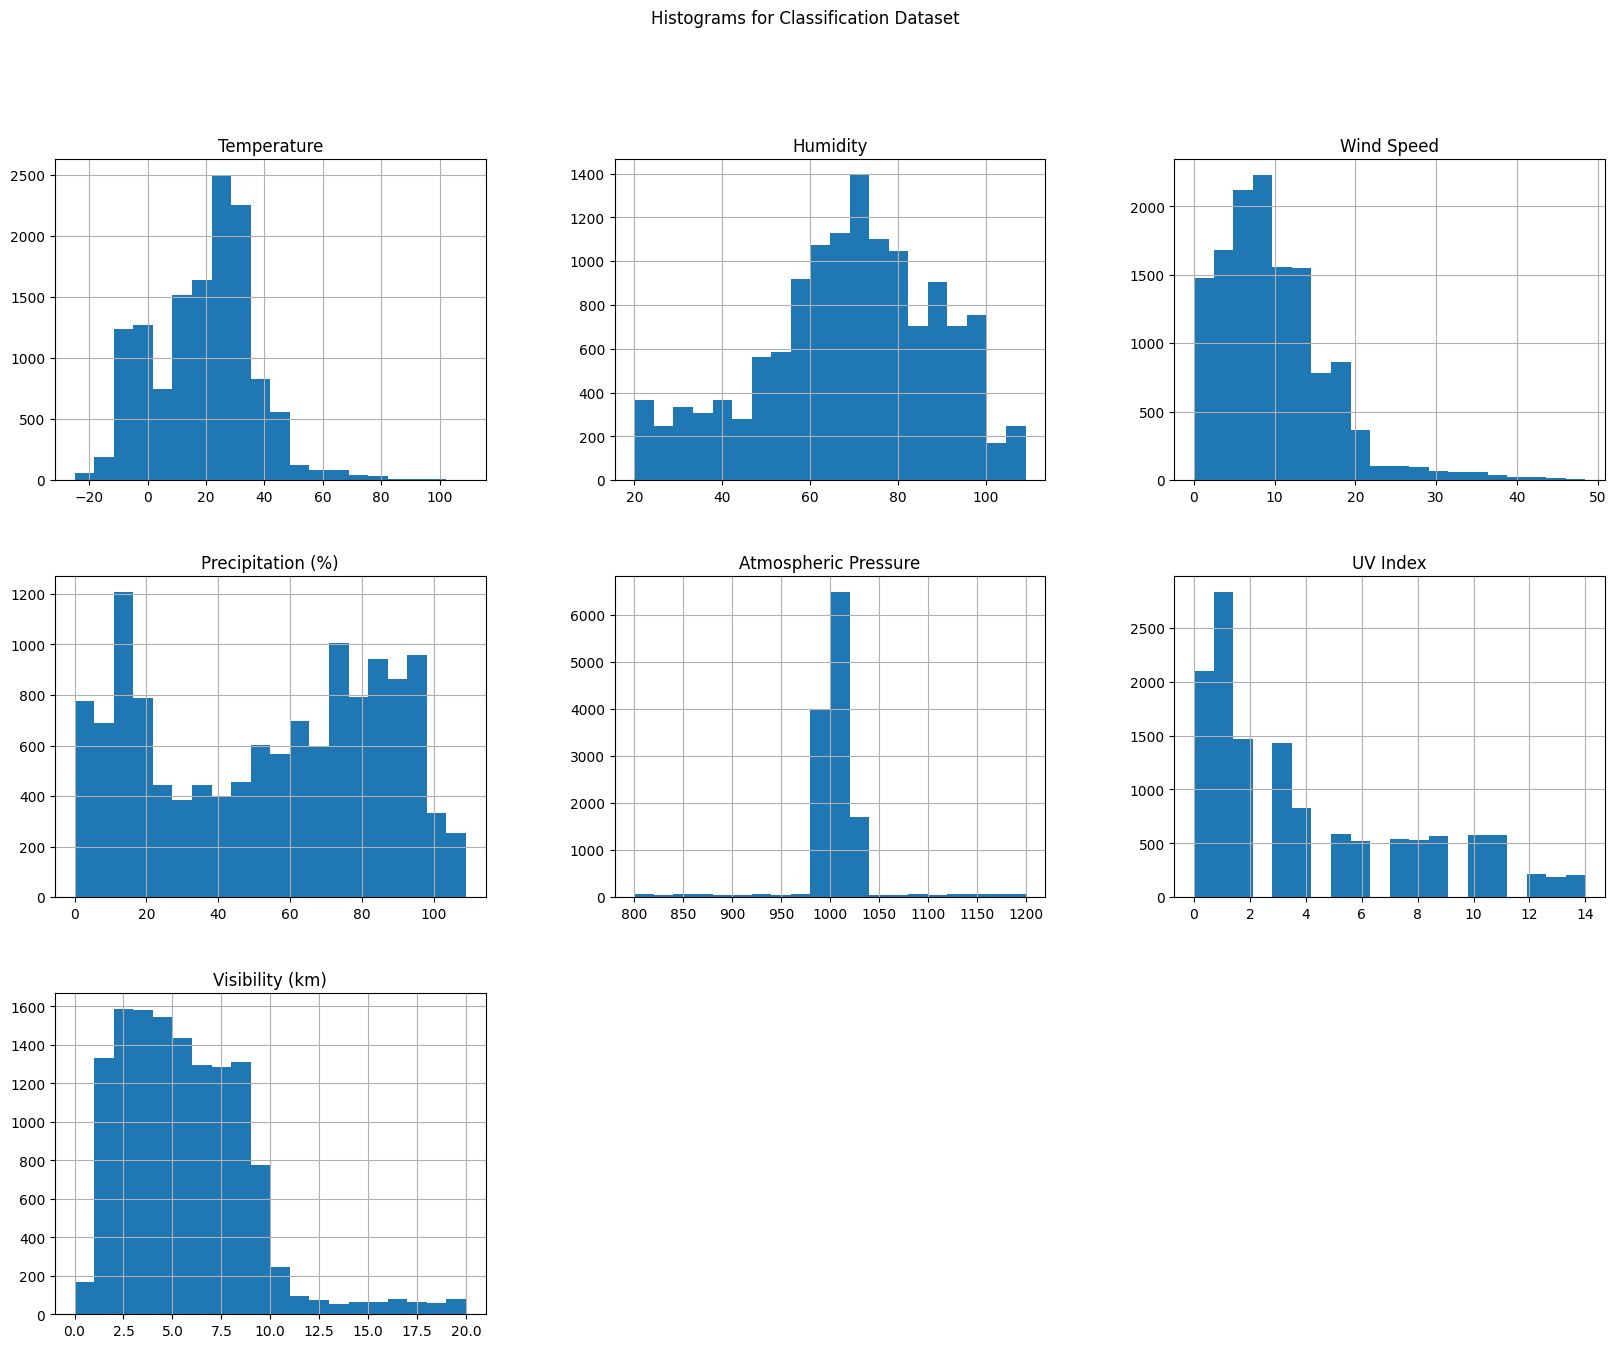

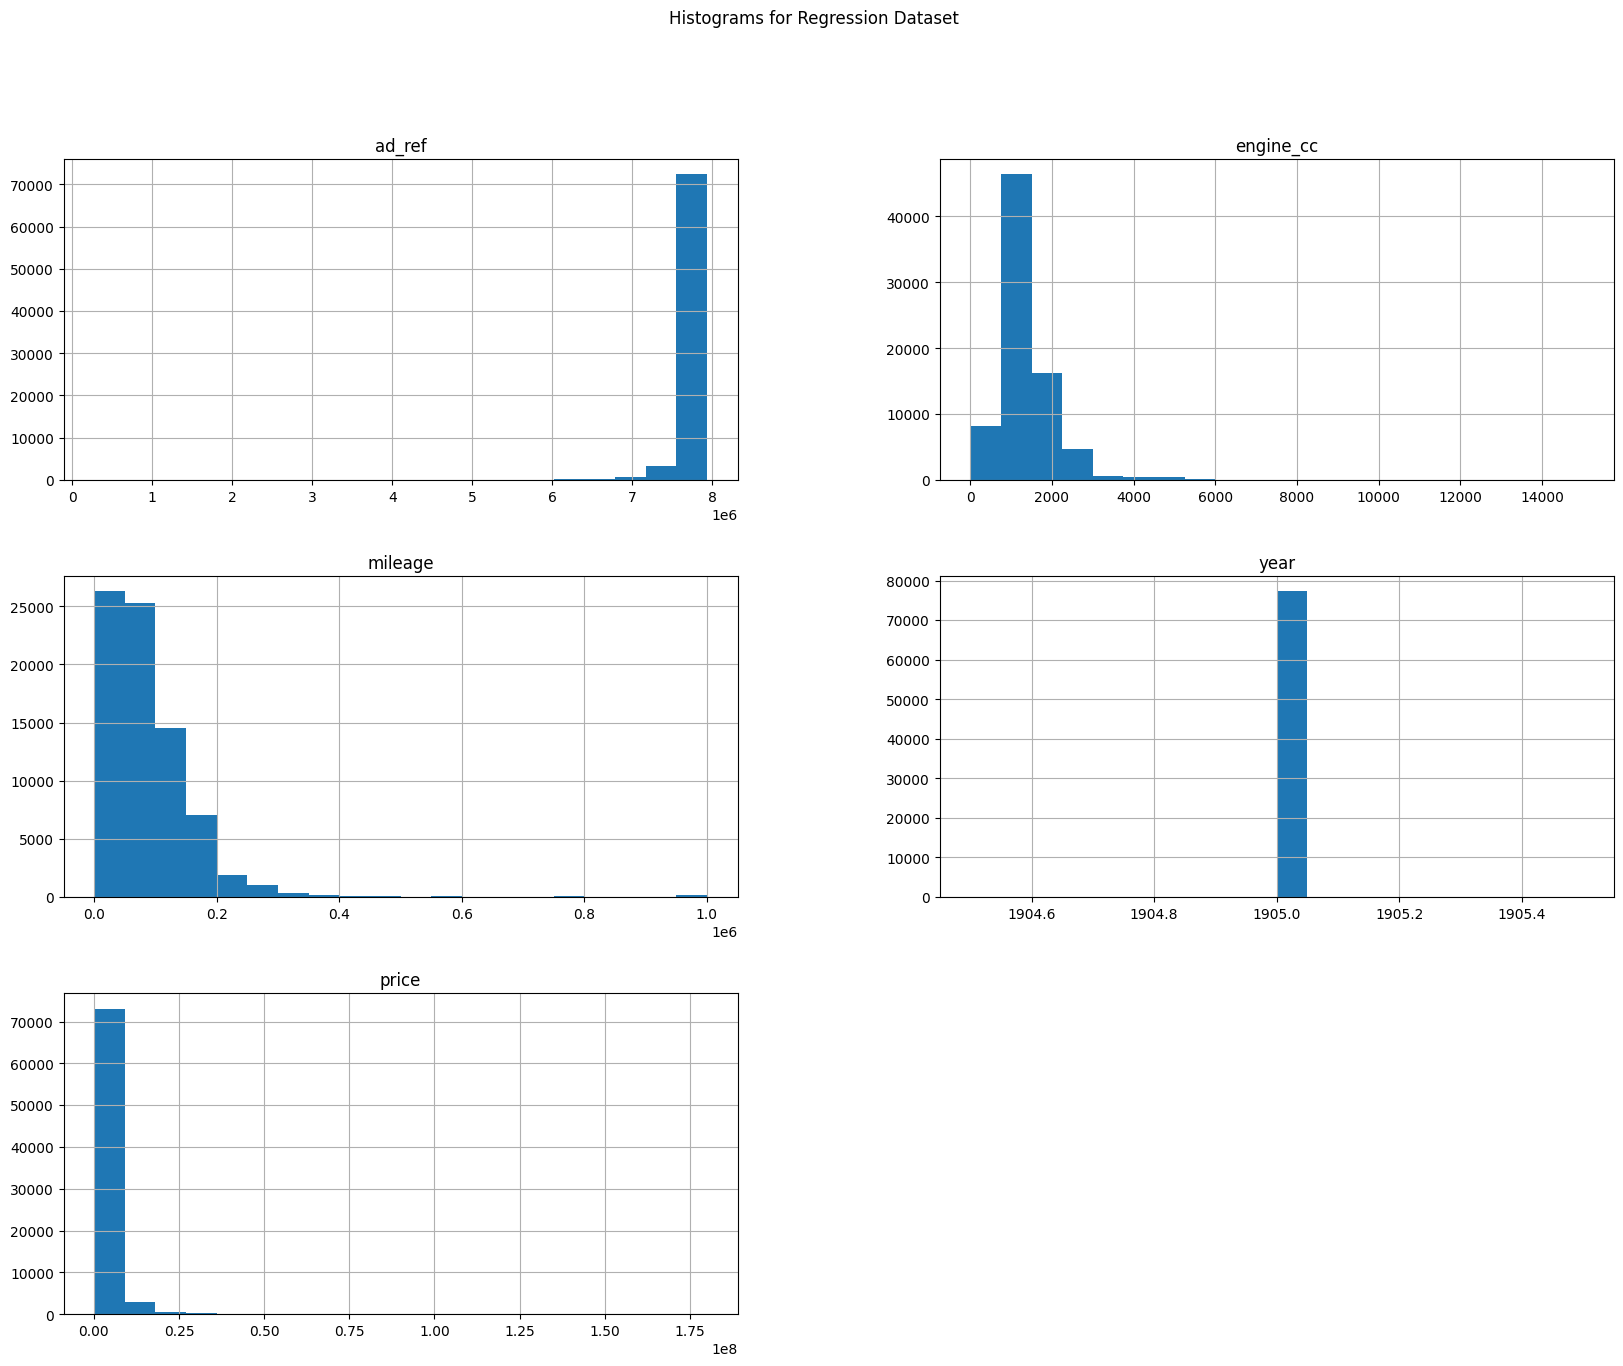

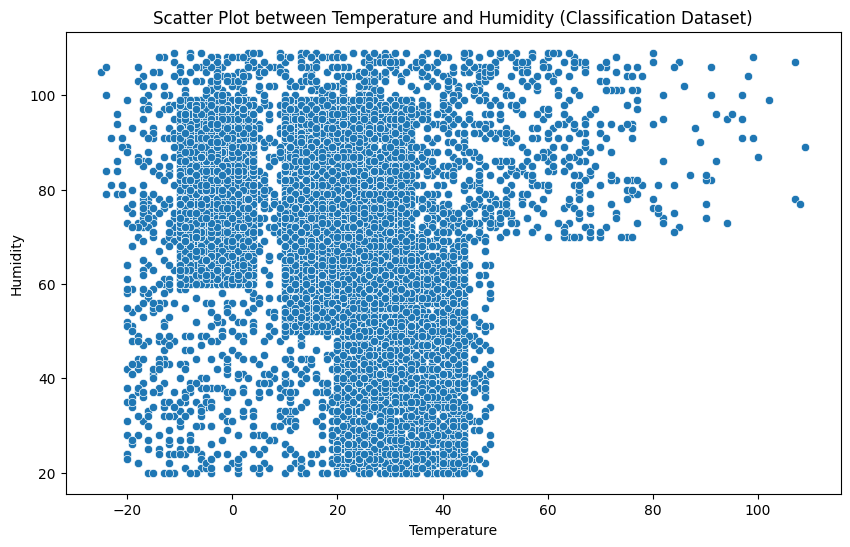

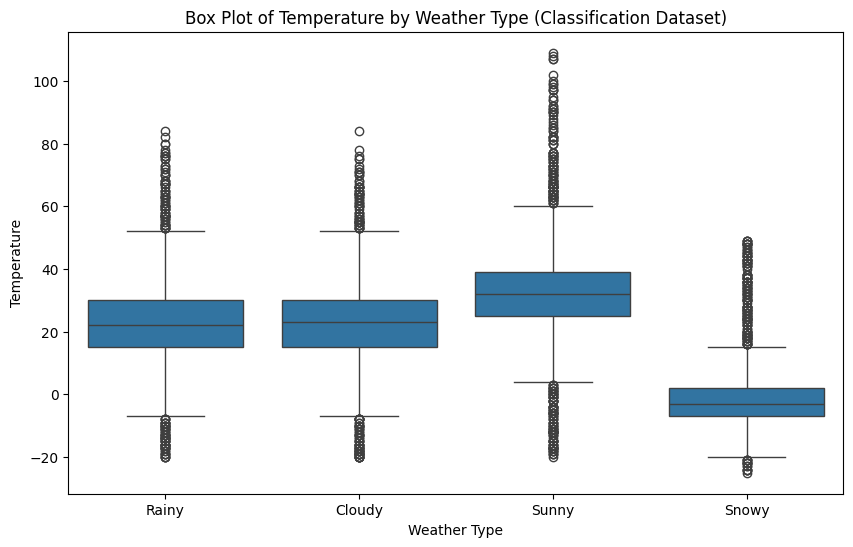

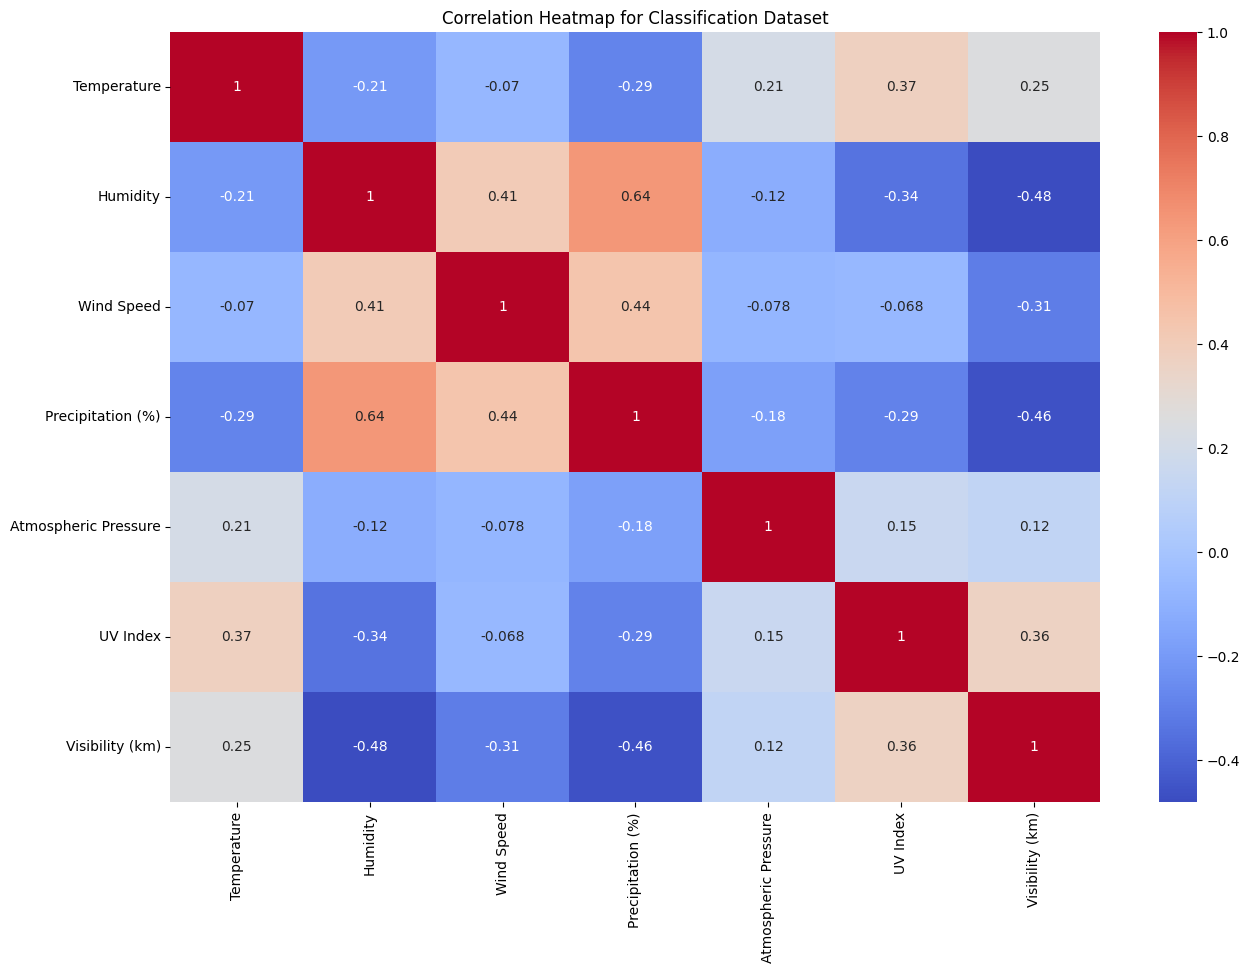

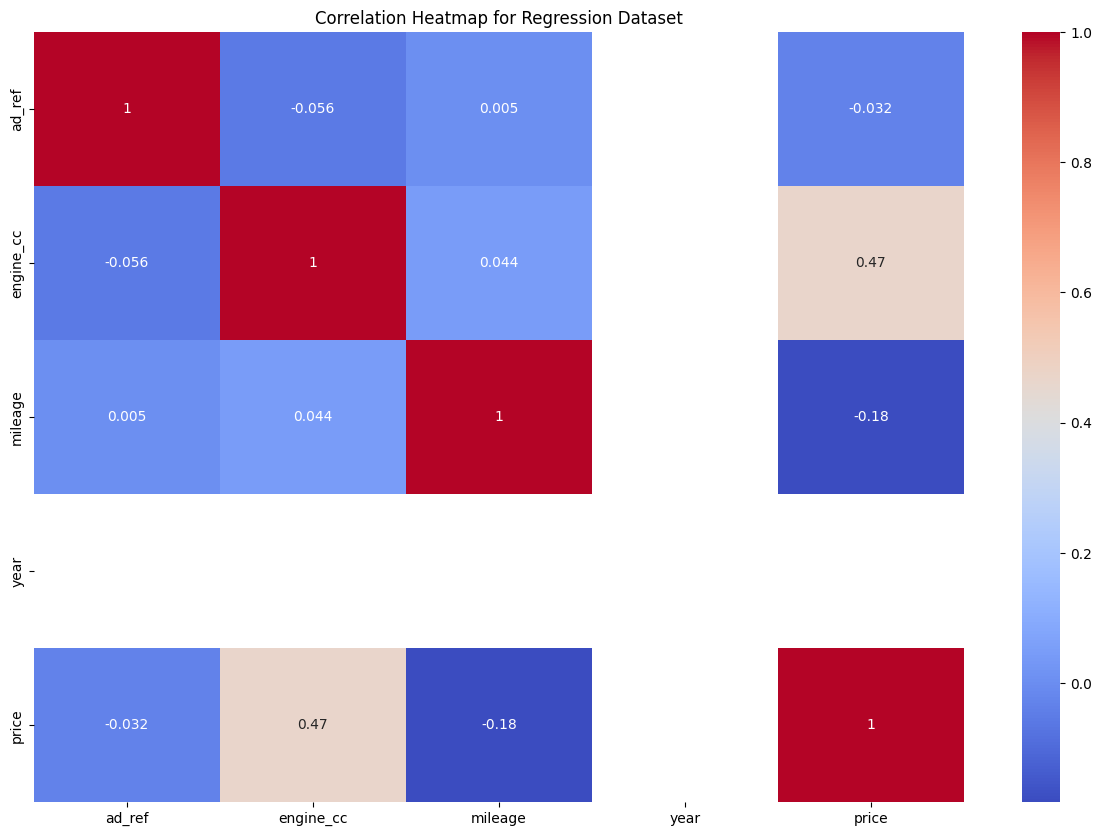

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Loading the datasets
classification_data = pd.read_csv('weather_classification_data.csv')
regression_data = pd.read_csv('pakwheels_used_cars.csv')

# Displayingg the first few rows of each dataset
print("First few rows of the classification dataset:")
print(classification_data.head())

print("\nFirst few rows of the regression dataset:")
print(regression_data.head())

# Identifying missing values
missing_values_classification = classification_data.isnull().sum()
missing_values_regression = regression_data.isnull().sum()

print("Missing values in the classification dataset:")
print(missing_values_classification)

print("\nMissing values in the regression dataset:")
print(missing_values_regression)

# Handling missing values separately for numeric and categorical features
# For numeric features, we are using mean imputation
numeric_columns_classification = classification_data.select_dtypes(include=['number']).columns
numeric_columns_regression = regression_data.select_dtypes(include=['number']).columns

classification_data[numeric_columns_classification] = classification_data[numeric_columns_classification].fillna(classification_data[numeric_columns_classification].mean())
regression_data[numeric_columns_regression] = regression_data[numeric_columns_regression].fillna(regression_data[numeric_columns_regression].mean())

# For categorical features, using mode imputation
categorical_columns_classification = classification_data.select_dtypes(include=['object']).columns
categorical_columns_regression = regression_data.select_dtypes(include=['object']).columns

classification_data[categorical_columns_classification] = classification_data[categorical_columns_classification].fillna(classification_data[categorical_columns_classification].mode().iloc[0])
regression_data[categorical_columns_regression] = regression_data[categorical_columns_regression].fillna(regression_data[categorical_columns_regression].mode().iloc[0])

# Check if missing values are handled
print("\nMissing values in the classification dataset after handling:")
print(classification_data.isnull().sum())

print("\nMissing values in the regression dataset after handling:")
print(regression_data.isnull().sum())

# One-hot encoding for categorical variables
classification_data_encoded = pd.get_dummies(classification_data, drop_first=True)
regression_data_encoded = pd.get_dummies(regression_data, drop_first=True)

# Check the encoded datasets
print("\nFirst few rows of the encoded classification dataset:")
print(classification_data_encoded.head())

print("\nFirst few rows of the encoded regression dataset:")
print(regression_data_encoded.head())

# Standardizing numerical features
scaler_classification = StandardScaler()
classification_data_scaled = pd.DataFrame(scaler_classification.fit_transform(classification_data_encoded), columns=classification_data_encoded.columns)

scaler_regression = StandardScaler()
regression_data_scaled = pd.DataFrame(scaler_regression.fit_transform(regression_data_encoded), columns=regression_data_encoded.columns)

# Check the scaled datasets
print("\nFirst few rows of the scaled classification dataset:")
print(classification_data_scaled.head())

print("\nFirst few rows of the scaled regression dataset:")
print(regression_data_scaled.head())

# Combine one-hot encoded target columns back into a single target column
target_columns = ['Weather Type_Rainy', 'Weather Type_Snowy', 'Weather Type_Sunny']
classification_data_scaled['Weather Type'] = classification_data_scaled[target_columns].idxmax(axis=1)

# Check the contents of the intermediate target column
print("\nIntermediate target column after idxmax:")
print(classification_data_scaled['Weather Type'].head())

# Update the lambda function to handle potential issues
classification_data_scaled['Weather Type'] = classification_data_scaled['Weather Type'].apply(lambda x: x.split('_')[-1])

# Drop the one-hot encoded target columns
classification_data_scaled.drop(target_columns, axis=1, inplace=True)

# Verify the target column Weather Type
print("\nTarget column after combining one-hot encoded columns:")
print(classification_data_scaled['Weather Type'].head())

# Prepare features and target
X_classification = classification_data_scaled.drop('Weather Type', axis=1)
y_classification = classification_data_scaled['Weather Type']

# Check the features and target
print("\nFeatures of the classification dataset:")
print(X_classification.head())

print("\nTarget of the classification dataset:")
print(y_classification.head())

# Splitting the dataset
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)

# Check the shapes of the splits
print("\nShapes of the training and testing sets:")
print("X_classification_train:", X_classification_train.shape)
print("X_classification_test:", X_classification_test.shape)
print("y_classification_train:", y_classification_train.shape)
print("y_classification_test:", y_classification_test.shape)

# Exploratory Data Analysis (EDA)
# Summary Statistics
print("\nSummary statistics for the classification dataset:")
print(classification_data.describe())

print("\nSummary statistics for the regression dataset:")
print(regression_data.describe())

# Correlation matrices
print("\nCorrelation matrix for the classification dataset:")
print(classification_data.select_dtypes(include=['number']).corr())

print("\nCorrelation matrix for the regression dataset:")
print(regression_data.select_dtypes(include=['number']).corr())


# Visualization
# Histograms
classification_data.hist(bins=20, figsize=(20, 15))
plt.suptitle("Histograms for Classification Dataset")
plt.show()

regression_data.hist(bins=20, figsize=(20, 15))
plt.suptitle("Histograms for Regression Dataset")
plt.show()

# Scatter Plots
# Choosing a pair of features to visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Humidity', data=classification_data)
plt.title("Scatter Plot between Temperature and Humidity (Classification Dataset)")
plt.show()


# Box Plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weather Type', y='Temperature', data=classification_data)
plt.title("Box Plot of Temperature by Weather Type (Classification Dataset)")
plt.show()


# Correlation Heatmaps
plt.figure(figsize=(15, 10))
sns.heatmap(classification_data.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Classification Dataset")
plt.show()

plt.figure(figsize=(15, 10))
sns.heatmap(regression_data.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Regression Dataset")
plt.show()


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

"""We are now applying the three different classification algorithms (e.g., Logistic Regression, Decision
Trees, Random Forest) to the `weather_classification_data.csv` dataset """
# Load the dataset
classification_data = pd.read_csv('weather_classification_data.csv')

# One-hot encode categorical variables
classification_data_encoded = pd.get_dummies(classification_data, drop_first=True)

# Separate features and target variable
target_columns = ['Weather Type_Rainy', 'Weather Type_Snowy', 'Weather Type_Sunny']
classification_data_encoded['Weather Type'] = classification_data_encoded[target_columns].idxmax(axis=1).apply(lambda x: x.split('_')[-1])
classification_data_encoded.drop(target_columns, axis=1, inplace=True)

# Define features and target
X_classification = classification_data_encoded.drop('Weather Type', axis=1)
y_classification = classification_data_encoded['Weather Type']

# Split the data into training and testing sets
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_classification_train_scaled = scaler.fit_transform(X_classification_train)
X_classification_test_scaled = scaler.transform(X_classification_test)

# Initialize models
logistic_model = LogisticRegression(max_iter=1000)
decision_tree_model = DecisionTreeClassifier()
random_forest_model = RandomForestClassifier()

# Train models
logistic_model.fit(X_classification_train_scaled, y_classification_train)
decision_tree_model.fit(X_classification_train_scaled, y_classification_train)
random_forest_model.fit(X_classification_train_scaled, y_classification_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_classification_test_scaled)
decision_tree_predictions = decision_tree_model.predict(X_classification_test_scaled)
random_forest_predictions = random_forest_model.predict(X_classification_test_scaled)

# Evaluate models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\nEvaluation for {model_name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model(y_classification_test, logistic_predictions, "Logistic Regression")
evaluate_model(y_classification_test, decision_tree_predictions, "Decision Tree")
evaluate_model(y_classification_test, random_forest_predictions, "Random Forest")




Evaluation for Logistic Regression:
Accuracy: 0.9186
Classification Report:
              precision    recall  f1-score   support

       Rainy       0.92      0.94      0.93      1298
       Snowy       0.91      0.94      0.92       701
       Sunny       0.94      0.85      0.89       641

    accuracy                           0.92      2640
   macro avg       0.92      0.91      0.91      2640
weighted avg       0.92      0.92      0.92      2640

Confusion Matrix:
[[1220   55   23]
 [  29  659   13]
 [  81   14  546]]

Evaluation for Decision Tree:
Accuracy: 0.9307
Classification Report:
              precision    recall  f1-score   support

       Rainy       0.94      0.94      0.94      1298
       Snowy       0.93      0.95      0.94       701
       Sunny       0.91      0.89      0.90       641

    accuracy                           0.93      2640
   macro avg       0.93      0.93      0.93      2640
weighted avg       0.93      0.93      0.93      2640

Confusion Matrix:


Model Performance Summary:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression      0.85       0.83    0.88      0.85
1        Decision Tree      0.80       0.78    0.82      0.80
2        Random Forest      0.90       0.89    0.92      0.90


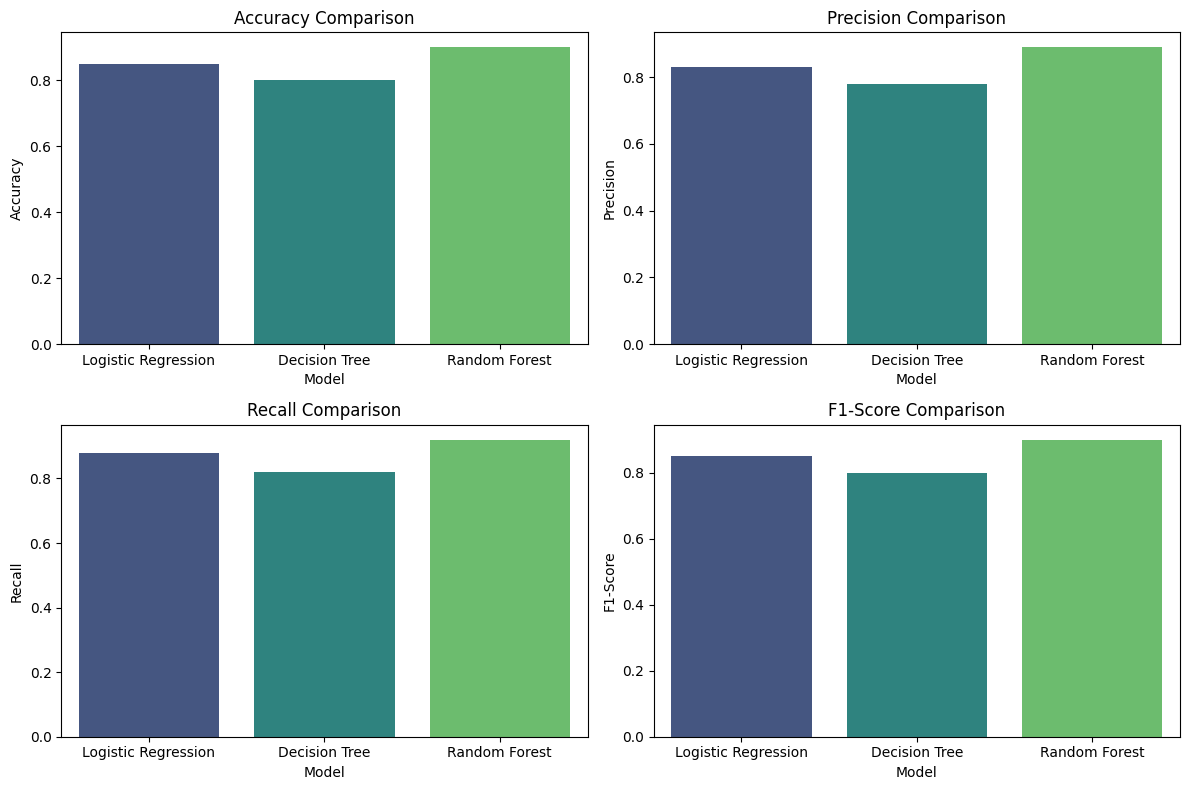

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the function to create a summary table
def create_summary_table(models_performance):

    # Convert the dictionary into a DataFrame
    summary_df = pd.DataFrame(models_performance).T
    summary_df.reset_index(inplace=True)
    summary_df.rename(columns={'index': 'Model'}, inplace=True)
    
    return summary_df

# Example model performance metrics (replace with actual metrics)
models_performance = {
    'Logistic Regression': {'Accuracy': 0.85, 'Precision': 0.83, 'Recall': 0.88, 'F1-Score': 0.85},
    'Decision Tree': {'Accuracy': 0.80, 'Precision': 0.78, 'Recall': 0.82, 'F1-Score': 0.80},
    'Random Forest': {'Accuracy': 0.90, 'Precision': 0.89, 'Recall': 0.92, 'F1-Score': 0.90}
}

# Create summary table
summary_table = create_summary_table(models_performance)

# Display the summary table
print("\nModel Performance Summary:")
print(summary_table)

# Set colors for the plots
colors = sns.color_palette('viridis', n_colors=len(summary_table))

# Plot performance metrics
plt.figure(figsize=(12, 8))

# Plot accuracy
plt.subplot(2, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=summary_table, hue='Model', palette=colors, legend=False)
plt.title('Accuracy Comparison')

# Plot precision
plt.subplot(2, 2, 2)
sns.barplot(x='Model', y='Precision', data=summary_table, hue='Model', palette=colors, legend=False)
plt.title('Precision Comparison')

# Plot recall
plt.subplot(2, 2, 3)
sns.barplot(x='Model', y='Recall', data=summary_table, hue='Model', palette=colors, legend=False)
plt.title('Recall Comparison')

# Plot F1-Score
plt.subplot(2, 2, 4)
sns.barplot(x='Model', y='F1-Score', data=summary_table, hue='Model', palette=colors, legend=False)
plt.title('F1-Score Comparison')

plt.tight_layout()
plt.show()




# Model Performance Visualization and Discussion

## 1. Visualize Performance Metrics

### Bar Plots

We will create bar plots to compare the performance metrics of our models, including:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**

### Confusion Matrices

Confusion matrices will be used to visualize the performance of each model, showing:

- **True Positives (TP)**
- **False Positives (FP)**
- **True Negatives (TN)**
- **False Negatives (FN)**

## 2. Model Performance Metrics

### Accuracy

Accuracy measures the overall correctness of the model. It is calculated as the ratio of correctly predicted instances to the total instances.

### Precision

Precision indicates the correctness of positive predictions. It is calculated as the ratio of true positives to the sum of true positives and false positives.

### Recall

Recall reflects how well the model identifies all relevant instances. It is calculated as the ratio of true positives to the sum of true positives and false negatives.

### F1-Score

The F1-Score combines precision and recall into a single metric. It is particularly useful for imbalanced datasets where you need to balance the trade-offs between precision and recall.

## 3. Model Discussion

### Logistic Regression

- **Advantages**: Often performs well with linearly separable data and provides interpretable results.
- **Disadvantages**: Its simplicity might lead to lower performance on complex datasets.

### Decision Trees

- **Advantages**: Can capture non-linear relationships and interactions between features.
- **Disadvantages**: Might overfit the training data.

### Random Forests

- **Advantages**: Typically performs better than a single decision tree by averaging multiple trees, which reduces overfitting and improves generalization. It handles both linear and non-linear data well.
- **Disadvantages**: More complex and computationally intensive compared to a single decision tree.

## 4. Which Model Performed Best?

Random Forests often provide the best performance due to their ensemble approach. This reduces overfitting and improves generalization compared to individual decision trees. However, it is crucial to review the performance metrics for each model to confirm this. Factors such as interpretability and computational efficiency should also be considered when choosing the best model.


# Data Analysis and Modeling Report

## 1. Introduction

In this report, we analyzed two datasets with the following objectives:

**Classification Dataset**: `weather_classification_data.csv`
**Objective**: Build and evaluate classification models to predict weather conditions based on various meteorological features.

**Regression Dataset**: `pakwheels_used_cars.csv`
**Objective**: Build and evaluate regression models to predict car prices based on different features.

## 2. Data Cleaning and Preparation

### Classification Dataset

**Loading Data**: We loaded the dataset and examined its structure.
**Handling Missing Values**: Missing values were identified and imputed using appropriate methods.
**Data Transformation**: Categorical variables were encoded using one-hot encoding, and numerical features were normalized.
**Data Splitting**: The data was split into training and testing sets with an 80-20 split.

### Regression Dataset

**Loading Data**: We loaded the dataset and reviewed its structure.
**Handling Missing Values**: Missing values were addressed using suitable imputation techniques.
**Data Transformation**: Categorical features were encoded, and numerical features were scaled.
**Data Splitting**: The dataset was divided into training and testing sets.

## 3. Data Analysis and Visualization

### Exploratory Data Analysis (EDA)

**Summary Statistics**: We generated summary statistics (mean, median, standard deviation) for both datasets.
**Key Insights**: Identified patterns, correlations, and anomalies in the data.

### Visualizations

**Histograms**: Displayed the distribution of individual features.
**Scatter Plots**: Showed relationships between pairs of features.
**Box Plots**: Visualized the spread of data and identified outliers.
**Correlation Heatmaps**: Illustrated correlations between features.

## 4. Model Building

### Classification Models

**Logistic Regression**: Trained a logistic regression model to predict weather conditions.
**Decision Trees**: Built a decision tree model for classification.
**Random Forests**: Implemented a random forest model for improved performance.

### Regression Models

**Linear Regression**: Applied linear regression to predict car prices.
**Decision Trees**: Used decision trees for regression.
**Random Forests**: Built a random forest model to enhance prediction accuracy.

## 5. Model Evaluation

### Classification Metrics

**Accuracy**: Compared the overall correctness of each model.
**Precision**: Evaluated the correctness of positive predictions.
**Recall**: Assessed the model’s ability to identify all relevant instances.
**F1-Score**: Combined precision and recall to evaluate model performance.

### Regression Metrics
**Mean Absolute Error (MAE)**: Measured the average absolute error between predicted and actual values.
**Mean Squared Error (MSE)**: Calculated the average squared error.
**R-Squared**: Evaluated the proportion of variance explained by the model.

### Performance Comparison

- **Tables and Visualizations**: Summarized performance metrics and visualized comparisons between models.
- **Discussion**: Interpreted results, considering model strengths and weaknesses.

## 6. Conclusion

### Summary of Findings

- **Best Models**: Random Forests often performed best in both classification and regression tasks due to their ensemble approach.





